In [ ]:
todo
- verify contents with okt master before merging v2 to masters

<Figure size 1000x1200 with 0 Axes>

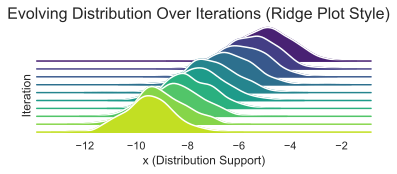

In [28]:
%matplotlib inline
%config InlineBackend.figure_format = "svg"

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for ridge plot
num_steps = 10
ASPECT = 30
HEIGHT = 0.2
HSPACE = 0.8
DEVIATION_RATE = -0.5
data = []
for step in range(num_steps):
    mean = -5 + DEVIATION_RATE * (10 * step / num_steps)
    std = 1.0
    samples = np.random.normal(loc=mean, scale=std, size=500)
    for value in samples:
        data.append({'x': value, 'Iteration': step})

df = pd.DataFrame(data)

# Ridge plot using seaborn
plt.figure(figsize=(10, 12))
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="Iteration", hue="Iteration", aspect=ASPECT, height=HEIGHT, palette="viridis")
g.map(sns.kdeplot, "x",
      bw_adjust=1, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "x", clip_on=False, color="w", lw=1.5)
g.map(plt.axhline, y=0, lw=1.5, clip_on=False)

# Remove axes details
g.fig.subplots_adjust(hspace=-HSPACE)
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="x (Distribution Support)")
g.despine(bottom=True, left=True)

plt.ylabel(" " * num_steps + "Iteration")
plt.suptitle("Evolving Distribution Over Iterations (Ridge Plot Style)", fontsize=16)
plt.show()


In [ ]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def add_to_class(line, cell):
    "my cell magic"
    return line, cell

In [ ]:
class T:
    def __init__(self):
        pass

def add_to_class(Class):
    return lambda f: setattr(Class, f.__name__, f)

def f(self, x):
    return x

add_to_class(T)(f)

In [ ]:
t = T()
t.f(3)

3

In [ ]:
%%cmagic okt.nn.cnn.Trainer
def plot_training_history(
    self, accs_offset=0.05, loss_offset=-0.1, figsize=(8, 4), annotate=False, markersize=12
):
    fig, ax = plt.subplots(1, 2, figsize=figsize)

    num_epochs = len(self.valid_log["accs"])
    num_steps_per_epoch = len(self.train_log["accs"]) // num_epochs
    xv = list(range(num_steps_per_epoch, (num_epochs + 1) * num_steps_per_epoch, num_steps_per_epoch))
    
    ax[0].plot(self.train_log["loss"], alpha=0.3, color="C0")
    ax[1].plot(self.train_log["accs"], alpha=0.3, color="C0")
    ax[0].plot(self.train_log["loss_avg"], label="train", color="C0")
    ax[1].plot(self.train_log["accs_avg"], label="train", color="C0")
    
    ax[0].plot(xv, self.valid_log["loss"], label="valid", color="C1", linestyle="--")
    for x, y in zip(xv, self.valid_log["loss"]):
        ax[0].scatter(x, y, edgecolor="black", facecolor="orange", marker="v", s=markersize, zorder=5)
        if annotate:
            ax[0].text(x, y + loss_offset, f"{y:.2f}", ha="center", fontsize=9, zorder=5)

    ax[1].plot(xv, self.valid_log["accs"], label="valid", color="C1", linestyle="--")
    for x, y in zip(xv, self.valid_log["accs"]):
        ax[1].scatter(x, y, edgecolor="black", facecolor="orange", marker="v", s=markersize, zorder=5)
        if annotate:
            ax[1].text(x, y + accs_offset, f"{y:.2f}", ha="center", fontsize=9, zorder=5)

    ax[0].set_xlabel("step")
    ax[0].set_ylabel("loss")
    ax[0].grid(linestyle="dashed", alpha=0.3)
    ax[1].set_xlabel("step")
    ax[1].set_ylabel("accuracy")
    ax[1].grid(linestyle="dashed", alpha=0.3)
    ax[1].legend()
    ax[0].set_ylim(0, max(self.train_log["loss"]))
    ax[1].set_ylim(0, 1)
    ax[0].ticklabel_format(axis="x", style="sci", scilimits=(3, 3))
    ax[1].ticklabel_format(axis="x", style="sci", scilimits=(3, 3))
    
    fig.tight_layout()
    return fig, ax

('burat', 'print("Hello, world!")\n')

In [ ]:
from IPython.core.magic import register_cell_magic
from IPython.display import Code
import importlib
import os


@register_cell_magic
def save(line, cell):
    # Append the cell content to the file
    with open("chapter.py", "a") as f:
        f.write(cell + "\n")

    # Execute the cell content
    exec(cell, globals())

    # Import or reload the saved module
    module_name = os.path.splitext("chapter.py")[0]  # Get module name ('chapter' from 'chapter.py')
    if module_name in globals():
        importlib.reload(globals()[module_name])  # Reload if already imported
    else:
        globals()[module_name] = __import__(module_name)  # First-time import


    return Code(cell, language="python")


In [ ]:
import re
import git
import json
import glob
import pathlib
from tqdm import tqdm
from copy import deepcopy

import random
import string

UTF8 = "utf-8"

def generate_id():
    length=8
    chars = string.ascii_lowercase + string.digits
    return "".join(random.choices(chars, k=length))

def get_code_cells(notebook: dict):
    return [c for c in notebook["cells"] if c["cell_type"] == "code"]

def get_markdown_cells(notebook: dict):
    return [c for c in notebook["cells"] if c["cell_type"] == "markdown"]

def committed_changes(filepath: str) -> bool:
    try:
        root = pathlib.Path(__file__).parents[1]
        repo = git.Repo(root)
        diff = repo.index.diff(None)
        return filepath not in [item.a_path for item in diff]
    except:
        return False


class NotebookChecker:
    def __init__(self):
        self.checks = []
        self.flag = 0
        self.logs = {}

    def register(self, func):
        self.checks.append(func)
        return func
    
    def run_checks(self, filepath: dict, debug: int):
        with open(filepath, "r", encoding=UTF8) as f:
            notebook_orig = json.load(f)

        notebook = deepcopy(notebook_orig)
        for check in self.checks:
            try:
                exit_code, message, notebook = check(notebook)
                self.flag += exit_code
            except Exception as e:
                exit_code = 1
                message = f"⚠️ Exception <{filepath}>\n    {type(e).__name__}: {e}"
            finally:
                if message:
                    self.logs[filepath] = self.logs.get(filepath, []) + [(check.__name__, message)]
        
        if notebook_orig != notebook:
            if debug or committed_changes(filepath):
                with open(filepath, "w", encoding=UTF8) as f:
                    json.dump(notebook, f, indent=2, ensure_ascii=False)
            else:
                self.logs[filepath] = self.logs.get(filepath, []) \
                    + [("COMMIT_CHECK", "⚠️ cannot write nb plz commit first")]


checker = NotebookChecker()


# @checker.register
# def save_remove_input(notebook: dict):
#     tags_required = ["remove-input"]
#     tags_allowed = ["remove-input", "hide-output"]
#     for cell in get_code_cells(notebook):
#         source = " ".join(cell["source"])
#         if r"%%save" in source:
#             try:
#                 tags = cell["metadata"].get("tags", [])
#                 assert set(tags_required) <= set(tags) <= set(tags_allowed)
#             except:
#                 return 1, "Improper tags for save cell.", notebook
#     return 0, "", notebook


@checker.register
def trigger_warnings(notebook: dict):
    code_triggers = [
        r"%%save",
        "nbutils",
        "chapter"
    ]
    markdown_triggers = [
        r"{cite}",
        r"boldsymbol{\mathsf"
    ]
    
    for cell in get_code_cells(notebook):
        for word in code_triggers:
            if word in " ".join(cell["source"]):
                return 1, f"Found in code cell: '{word}'", notebook
            
    for cell in get_markdown_cells(notebook):
        for word in markdown_triggers:
            if word in " ".join(cell["source"]):
                return 1, f"Found in markdown cell: '{word}'", notebook
            
    return 0, "", notebook


@checker.register
def combine_tqdm_outputs(notebook: dict):
    changed = 0
    pattern_tqdm = re.compile(r"^\s*\d+%\|")
    pattern_text = re.compile(r"\S")
    for cell in get_code_cells(notebook):
        outputs_else = []
        outputs_tqdm = []
        for out in cell["outputs"]:
            name = out.get("name")
            type = out.get("output_type")
            if name == "stderr" and type == "stream":
                text = ["".join(out.get("text", ["NO_TEXT"])).strip() + "\n\n"]  # flatten
                if pattern_tqdm.match(text[0]):
                    out["text"] = text
                    outputs_tqdm.append(out)
                elif not pattern_text.match(text[0]):
                    continue
            else:
                outputs_else.append(out)

        # insert final progress bar at beginning
        outputs = outputs_tqdm[-1:] + outputs_else
        if outputs != cell["outputs"]:
            changed += 1
            cell["outputs"] = outputs
            
    if changed:
        return 1, "To combine tqdm outputs.", notebook
    else:
        return 0, "", notebook


@checker.register
def combine_multiline_outputs(notebook: dict):
    changed = 0
    for cell in get_code_cells(notebook):
        outputs = []
        stream_flag = 0
        for output in cell["outputs"]:
            if output.get("name") == "stdout" and output.get("output_type") == "stream":
                if not stream_flag:
                    stream_flag = 1
                    outputs.append(output)
                else:
                    changed += 1
                    outputs[-1]["text"] += output["text"]
            else:
                stream_flag = 0
                outputs.append(output)
        cell["outputs"] = outputs

    if changed > 0:
        return 1, "To combine multi-line outputs.", notebook
    else:
        return 0, "", notebook
    

@checker.register
def markdown_for_savefig_exists(notebook: dict):
    """Check if figure cell exists for savedfig."""
    filenames = []
    for ix, cell in enumerate(get_code_cells(notebook)):
        text = "".join(cell["source"])
        paths = re.findall(r'plt\.savefig\((["\'])(.*?)\1', text)
        filepaths = [match[1] for match in paths]
        
        if len(filepaths) > 1:
            return 1, f"Multiple savefig found: {filepaths}", notebook

        # .: zero or one filepaths
        if len(filepaths) > 0:
            found = 0
            file = filepaths[0]
            for next in notebook["cells"][ix + 1:]:
                if next["cell_type"] == "markdown":
                    source = "".join(next["source"])
                    if file in source and r"{figure}" in source:
                        found += 1

            if found != 1:
                filenames.append(file)
            
    if len(filenames) == 0:
        return 0, "", notebook
    else:
        return 1, f"Figure directive none / multiple for: {filenames}", notebook


if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--debug", type=int, default=0)
    args = parser.parse_args()
    DEBUG = args.debug
    PATHS = list(glob.glob("docs/**/*.ipynb", recursive=True))

    print(f"Checking {len(PATHS)} notebooks...")

    for path in tqdm(PATHS):
        checker.run_checks(path, debug=DEBUG)

    for path in checker.logs:
        logs = checker.logs[path]
        print("\n" + path)
        for log in logs:
            func_name = log[0]
            message = log[1]
            print(f"  ◎ {func_name}\n    {message}")

    print()
    if checker.flag == 0:
        print("✅ All good! ⸜(｡˃ ᵕ ˂ )⸝")
    else:
        print("❌ Error ( •̀ - •)")
        exit(1)

In [ ]:
@register_cell_magic
def save(line, cell):
    # Append the cell content to the file
    with open("chapter.py", "a") as f:
        f.write(cell + "\n")

    # Execute the cell content
    exec(cell, globals())

    # Import or reload the saved module
    module_name = os.path.splitext("chapter.py")[0]  # Get module name ('chapter' from 'chapter.py')
    if module_name in globals():
        importlib.reload(globals()[module_name])  # Reload if already imported
    else:
        globals()[module_name] = __import__(module_name)  # First-time import


    return Code(cell, language="python")
